## Polynomial Regresisson

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('coffee.csv')
df.head()

,Temperature,Coffee_Sales
0,14.981605,150.800298
1,38.028572,122.531718
2,29.279758,120.509181
3,23.946339,117.580908
4,6.240746,178.483961


In [3]:
# features and target
x = df.iloc[: ,0:1]
y = df.iloc[:, -1]

<function matplotlib.pyplot.show(close=None, block=None)>

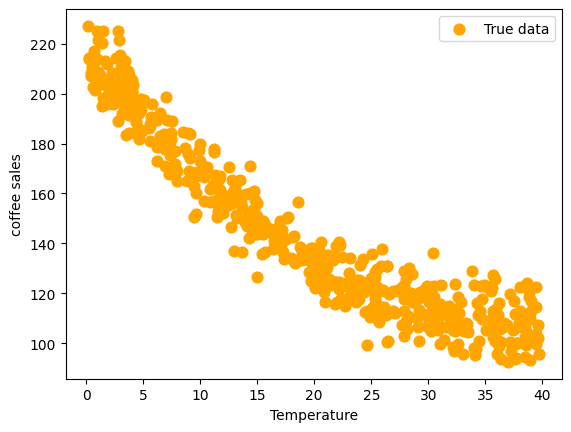

In [4]:
# scatter plot of True data
plt.scatter(x,y, color = 'orange', s = 60, label = 'True data')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show

In [5]:
# training Linear Regresison for comparison
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

# model train (Linear)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print('Intercept: ',lr.intercept_)
print('Coef: ',lr.coef_)
print('R2 Score: ',r2_score(y_test, y_pred_lr))

Intercept:  198.65484992971554
Coef:  [-2.76052583]
R2 Score:  0.8949310022825293


<function matplotlib.pyplot.show(close=None, block=None)>

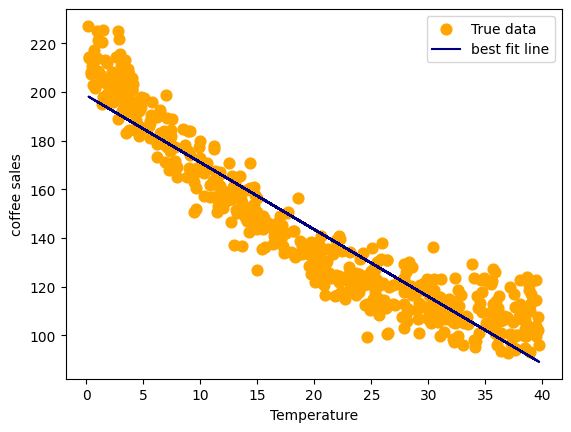

In [6]:
# best fit line plot
plt.scatter(x,y, color = 'orange', s = 60, label = 'True data')
plt.plot(x_test, y_pred_lr, color='navy', label = 'best fit line')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show

## Polynomial Features

In [8]:
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred = lr2.predict(x_test_trans)

print('Intercept: ',lr2.intercept_)
print('Coef: ',lr2.coef_)
print('R2 Score: ',r2_score(y_test, y_pred))

Intercept:  218.19124944213445
Coef:  [ 0.         -5.82381629  0.07675209]
R2 Score:  0.9489246136620054


In [9]:
# polynomial curve
x_new = np.linspace(x.min(), x.max(), 500).reshape(-1,1)
x_new_poly = poly.transform(x_new)
y_new = lr2.predict(x_new_poly)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

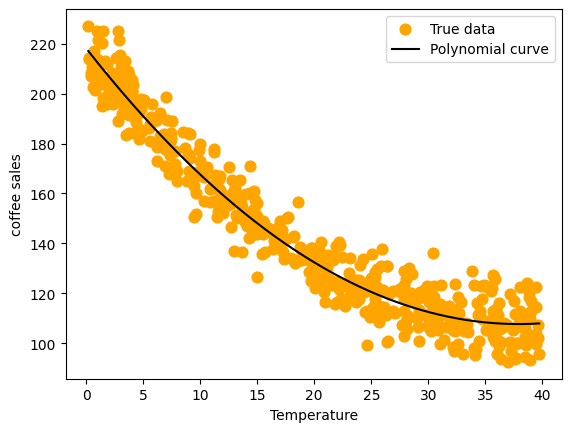

In [10]:
plt.scatter(x,y, color = 'orange', s = 60, label = 'True data')
plt.plot(x_new, y_new, color = 'k', label = 'Polynomial curve')
# plt.plot(x_test, y_pred_lr, color='navy', label = 'best fit line')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show

Prediction:  120.56589553926166


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


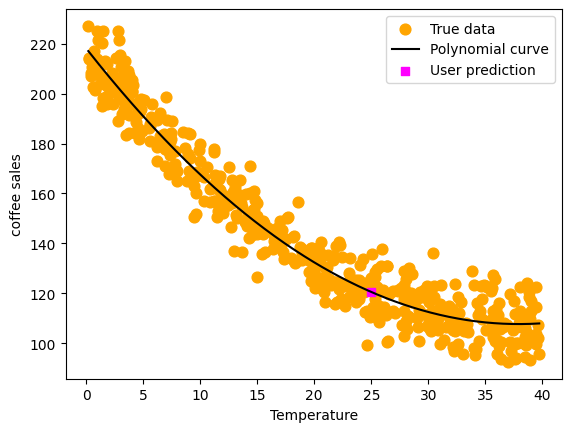

In [14]:
# User input and its prediction
temp = float(input('Enter Temperature: '))

temp_poly = poly.transform([[temp]])
prediction = lr2.predict(temp_poly)


plt.scatter(x,y, color = 'orange', s = 60, label = 'True data')
plt.plot(x_new, y_new, color = 'k', label = 'Polynomial curve')
plt.scatter(temp, prediction, color = 'magenta', marker = 's', label = 'User prediction')
plt.xlabel('Temperature')
plt.ylabel('coffee sales')
plt.legend()
plt.show
print('Prediction: ',prediction[0])